# EDA — Tech Challenge | Análise por UF e por Município

Este notebook apresenta **duas análises independentes**, mantendo o grão correto de cada base, e uma terceira seção de comparação:

1. **Análise por UF** — `UF × Ano × Série`
2. **Análise por Município** — `Município × UF × Ano × Série`
3. **Análise cruzada Município × UF** — comparação do município com sua referência estadual.

### Objetivo
Avaliar desempenho em Língua Portuguesa, alfabetização, metas, risco e contexto socioeconômico, gerando indicadores que apoiem a identificação de UFs e municípios que demandam maior atenção.

### Bases utilizadas
- `TS_ESTADO`: indicadores agregados por UF.
- `TS_MUNICIPIO`: indicadores agregados por município.
- `RESULTADOS_METAS`: metas estaduais.
- `RESULTADOS_METAS_MUNICIPIO`: metas municipais.
- `fact_municipio`: HAD, risco municipal/UF e contexto socioeconômico da UF.

> **TS_ALUNO não é utilizada nesta EDA.** O objetivo aqui é manter a análise nos níveis estadual e municipal e evitar a repetição de indicadores agregados em milhões de registros de alunos.

## 1. Imports e conexão com o S3

In [19]:
import os
import io
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import boto3
from dotenv import load_dotenv
from src.data.utils import *

def salvar_parquet(df, caminho):
    '''Salva um DataFrame em .parquet, garantindo nomes de coluna string
    (Parquet exige isso; leituras com header=None geram colunas inteiras
    0, 1, 2... que precisam virar "0", "1", "2"...) e tipagem homogênea por
    coluna (colunas "object" que misturam número e texto — ex.: os
    indicadores de HAD antes de tratar o marcador "--" — quebram a escrita
    em parquet, que exige um único tipo por coluna; aqui elas são
    convertidas para string, preservando nulos).'''
    df = df.rename(columns=str).copy()
    for col in df.columns:
        if df[col].dtype == "object":
            nulos = df[col].isna()
            df[col] = df[col].astype(str)
            df.loc[nulos, col] = None
    df.to_parquet(caminho, index=False)

load_dotenv()

session = iniciar_cessao_aws()
s3 = session.client("s3")
BUCKET = os.getenv("BUCKET_NAME")

if not BUCKET:
    raise ValueError("BUCKET_NAME não foi encontrado no .env.")

print("Bucket:", BUCKET)

Bucket: postech-challenge-datascience-003


In [21]:
BASE = Path.cwd()

INPUT_DIR = BASE.parent / 'src' / 'data' / 'raw'

OUTPUT_DIR = INPUT_DIR.parent

BRONZE_DIR = OUTPUT_DIR / "bronze"
SILVER_DIR = OUTPUT_DIR / "silver"
SILVER_DIM_DIR = SILVER_DIR / "dim"
GOLD_DIR = OUTPUT_DIR / "gold"

## 2. Leitura das bases Gold

In [3]:
# Bases principais do INEP
resultado_metas = carregar_parquet_s3(s3, BUCKET, "RESULTADOS_METAS", ano="historico")
resultado_metas_muni = carregar_parquet_s3(s3, BUCKET, "RESULTADOS_METAS_MUNICIPIO", ano="historico")
df_municipios = carregar_parquet_s3(s3, BUCKET, "TS_MUNICIPIO", ano="historico")
df_estados = carregar_parquet_s3(s3, BUCKET, "TS_ESTADO", ano="historico")

# fact_municipio fica em gold/dados_externos.
try:
    fact_municipio = carregar_parquet_s3(
        s3, BUCKET, "fact_municipio", subpasta="dados_externos"
    )
except Exception as e_helper:
    try:
        obj = s3.get_object(
            Bucket=BUCKET,
            Key="gold/dados_externos/fact_municipio.parquet"
        )
        fact_municipio = pd.read_parquet(io.BytesIO(obj["Body"].read()))
        print("fact_municipio carregada via leitura direta do S3.")
    except Exception as e_s3:
        fact_municipio = None
        print("[AVISO] fact_municipio não foi carregada.")
        print("Helper:", e_helper)
        print("S3 direto:", e_s3)

print("TS_MUNICIPIO:", df_municipios.shape)
print("TS_ESTADO:", df_estados.shape)
print("Metas Município:", resultado_metas_muni.shape)
print("Metas UF:", resultado_metas.shape)
if fact_municipio is not None:
    print("fact_municipio:", fact_municipio.shape)

Lendo: s3://postech-challenge-datascience-003/gold/ano=historico/dados/RESULTADOS_METAS.parquet
Lendo: s3://postech-challenge-datascience-003/gold/ano=historico/dados/RESULTADOS_METAS_MUNICIPIO.parquet
Lendo: s3://postech-challenge-datascience-003/gold/ano=historico/dados/TS_MUNICIPIO.parquet
Lendo: s3://postech-challenge-datascience-003/gold/ano=historico/dados/TS_ESTADO.parquet
Lendo: s3://postech-challenge-datascience-003/gold/dados_externos/fact_municipio.parquet
TS_MUNICIPIO: (36411, 20)
TS_ESTADO: (225, 18)
Metas Município: (16286, 20)
Metas UF: (84, 19)
fact_municipio: (21133, 14)


## 3. Padronização das chaves e funções auxiliares

In [4]:
# Padronização dos nomes de ano/UF
resultado_metas_muni = resultado_metas_muni.rename(columns={"ANO": "NU_ANO_AVALIACAO"})
resultado_metas = resultado_metas.rename(columns={"ANO": "NU_ANO_AVALIACAO", "CD_UF": "CO_UF"})

for df in [df_municipios, df_estados, resultado_metas_muni, resultado_metas]:
    for col in ["NU_ANO_AVALIACAO", "CO_UF", "CO_MUNICIPIO", "TP_SERIE", "ID_TIPO_REDE"]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

if fact_municipio is not None:
    fact_municipio = fact_municipio.rename(
        columns={"ANO": "NU_ANO_AVALIACAO", "COD_UF": "CO_UF"}
    )
    for col in ["NU_ANO_AVALIACAO", "CO_UF", "CO_MUNICIPIO"]:
        if col in fact_municipio.columns:
            fact_municipio[col] = pd.to_numeric(fact_municipio[col], errors="coerce")


def validar_chave_unica(df, chave, nome):
    duplicadas = df.duplicated(chave).sum()
    print(f"{nome}: {len(df):,} registros | {duplicadas:,} duplicidades na chave")
    if duplicadas:
        raise ValueError(f"{nome} possui duplicidade na chave {chave}.")


def cobertura(df, coluna, nome):
    if coluna in df.columns:
        print(f"{nome}: {df[coluna].notna().mean()*100:.2f}% preenchido")


def preparar_metas(df, chave, nivel):
    if not set(chave).issubset(df.columns):
        raise KeyError(f"Base de metas {nivel} sem a chave obrigatória: {chave}")

    candidatos = []
    for c in df.columns:
        u = str(c).upper()
        if u.startswith("META_") or u.startswith("VL_META") or "META_FINAL" in u:
            if c not in chave:
                candidatos.append(c)

    saida = df[chave + candidatos].copy()
    rename = {}
    for c in candidatos:
        u = str(c).upper()
        # Mantém o ano/origem no nome para evitar colisões entre metas.
        if u.startswith("META_MUN_"):
            novo = u.replace("META_MUN_", "META_MUNICIPIO_")
        elif u.startswith("META_UF_"):
            novo = u
        elif "META_FINAL" in u:
            novo = u.replace("META_FINAL", f"META_{nivel}_FINAL")
        else:
            novo = f"META_{nivel}_{u}"
        rename[c] = novo
    saida = saida.rename(columns=rename)
    validar_chave_unica(saida, chave, f"Metas {nivel}")
    return saida


def escolher_meta_ano(df, nivel, ano_col="NU_ANO_AVALIACAO"):
    """Seleciona automaticamente uma coluna de meta compatível com o ano da linha."""
    out = pd.Series(np.nan, index=df.index, dtype="float64")
    for ano in sorted(pd.to_numeric(df[ano_col], errors="coerce").dropna().unique()):
        ano = int(ano)
        prefixo = f"META_{nivel}_"
        candidatos = []
        for c in df.columns:
            u = str(c).upper()
            if u.startswith(prefixo) and str(ano) in u:
                candidatos.append(c)
        # Prefere coluna específica do ano; se houver mais de uma, usa a primeira com valor.
        mask = df[ano_col].eq(ano)
        for c in candidatos:
            valores = pd.to_numeric(df.loc[mask, c], errors="coerce")
            if valores.notna().any():
                out.loc[mask] = valores
                break
    return out

# PARTE A — ANÁLISE POR UF

**Grão analítico:** `CO_UF + Ano + Série`.

Nesta seção a unidade de análise é o Estado. Não calculamos média simples dos municípios para representar a UF: usamos diretamente o indicador estadual de `TS_ESTADO`.

## 4. Preparação da base estadual

In [5]:
colunas_uf = [
    "NU_ANO_AVALIACAO", "CO_UF", "TP_SERIE",
    "VL_MEDIA_LP", "PC_ALUNO_ALFABETIZADO"
]
faltantes = [c for c in colunas_uf if c not in df_estados.columns]
if faltantes:
    raise KeyError(f"TS_ESTADO sem colunas necessárias: {faltantes}")
if "ID_TIPO_REDE" not in df_estados.columns:
    raise KeyError("TS_ESTADO não possui ID_TIPO_REDE.")

df_uf = df_estados.loc[
    df_estados["ID_TIPO_REDE"].eq(5), colunas_uf
].copy()

df_uf = df_uf.rename(columns={
    "VL_MEDIA_LP": "MEDIA_LP_UF",
    "PC_ALUNO_ALFABETIZADO": "ALFABETIZACAO_UF"
})

chave_uf = ["NU_ANO_AVALIACAO", "CO_UF", "TP_SERIE"]
validar_chave_unica(df_uf, chave_uf, "TS_ESTADO — Total Geral")
print("Base UF:", df_uf.shape)
display(df_uf.head())

TS_ESTADO — Total Geral: 76 registros | 0 duplicidades na chave
Base UF: (76, 5)


,NU_ANO_AVALIACAO,CO_UF,TP_SERIE,MEDIA_LP_UF,ALFABETIZACAO_UF
2,2023,11,2,759.4357,64.60
4,2023,13,2,736.4687,52.20
6,2023,15,2,733.2877,48.38
10,2023,16,2,732.4277,41.56
12,2023,17,2,734.2853,43.72


## 5. Metas e contexto socioeconômico por UF

In [6]:
df_metas_uf = preparar_metas(
    resultado_metas,
    ["NU_ANO_AVALIACAO", "CO_UF"],
    "UF"
)

analise_uf = df_uf.merge(
    df_metas_uf,
    on=["NU_ANO_AVALIACAO", "CO_UF"],
    how="left",
    validate="many_to_one"
)

# O fact_municipio repete os indicadores agregados da UF para cada município.
# Para a análise por UF, reduzimos esse fato para uma linha por UF/Ano.
if fact_municipio is not None:
    cols_uf_ext = [
        "NU_ANO_AVALIACAO", "CO_UF", "COD_RISCO_UF", "CATEGORIA_RISCO_UF",
        "UF_POPULACAO_MIL", "UF_TAXA_ANALFABETISMO_PCT",
        "UF_RENDIMENTO_MEDIO_MENSAL_REAIS", "UF_RENDA_PERCAPITA_SBENEF_MEDIO",
        "UF_TAXA_FREQ_LIQUIDA_FUND_PCT", "UF_TIPO_DADO"
    ]
    cols_uf_ext = [c for c in cols_uf_ext if c in fact_municipio.columns]
    ext_uf = fact_municipio[cols_uf_ext].copy()
    chave_ext_uf = ["NU_ANO_AVALIACAO", "CO_UF"]
    ext_uf = ext_uf.sort_values(chave_ext_uf).drop_duplicates(chave_ext_uf, keep="first")

    analise_uf = analise_uf.merge(
        ext_uf,
        on=chave_ext_uf,
        how="left",
        validate="many_to_one"
    )

analise_uf["META_UF_REFERENCIA"] = escolher_meta_ano(analise_uf, "UF")
analise_uf["GAP_META_UF"] = analise_uf["ALFABETIZACAO_UF"] - analise_uf["META_UF_REFERENCIA"]
analise_uf["ATINGIU_META_UF"] = analise_uf["GAP_META_UF"].ge(0)

print("Base analítica UF:", analise_uf.shape)
display(analise_uf.head())

Metas UF: 84 registros | 0 duplicidades na chave
Base analítica UF: (76, 22)


,NU_ANO_AVALIACAO,CO_UF,TP_SERIE,MEDIA_LP_UF,ALFABETIZACAO_UF,META_UF_FINAL_2024,META_UF_FINAL_2025,META_UF_FINAL_2026,META_UF_FINAL_2027,META_UF_FINAL_2028,...,COD_RISCO_UF,CATEGORIA_RISCO_UF,UF_POPULACAO_MIL,UF_TAXA_ANALFABETISMO_PCT,UF_RENDIMENTO_MEDIO_MENSAL_REAIS,UF_RENDA_PERCAPITA_SBENEF_MEDIO,UF_TAXA_FREQ_LIQUIDA_FUND_PCT,META_UF_REFERENCIA,GAP_META_UF,ATINGIU_META_UF
0,2023,11,2,759.4357,64.60,67.1,69.5,71.9,74.1,76.2,...,5.0,Muito alto,94,5.1,2916,1524.801152,89.593066,NaN,NaN,False
1,2023,13,2,736.4687,52.20,56.8,61.3,65.6,69.6,73.4,...,3.0,Moderado,296,5.0,2549,1111.498981,92.050449,NaN,NaN,False
2,2023,15,2,733.2877,48.38,53.6,58.7,63.6,68.2,72.5,...,1.0,Muito baixo,546,7.0,2407,1206.913539,92.134734,NaN,NaN,False
3,2023,16,2,732.4277,41.56,47.6,53.8,59.9,65.6,70.9,...,5.0,Muito alto,53,5.7,3112,1474.726549,91.072491,NaN,NaN,False
4,2023,17,2,734.2853,43.72,49.5,55.4,61.1,66.5,71.5,...,5.0,Muito alto,98,7.7,2882,1544.327247,90.970356,NaN,NaN,False


## 6. Indicadores e ranking por UF

In [7]:
# Evolução da média estadual por ano e série
resumo_uf_ano = (
    analise_uf.groupby(["NU_ANO_AVALIACAO", "TP_SERIE"], as_index=False)
    .agg(
        MEDIA_LP_UF=("MEDIA_LP_UF", "mean"),
        ALFABETIZACAO_UF=("ALFABETIZACAO_UF", "mean"),
        GAP_META_UF=("GAP_META_UF", "mean")
    )
)

print("=== EVOLUÇÃO POR UF ===")
display(resumo_uf_ano.round(2))

# Ranking geral de UFs no último ano disponível.
ano_uf = int(analise_uf["NU_ANO_AVALIACAO"].max())
ranking_uf = (
    analise_uf.loc[analise_uf["NU_ANO_AVALIACAO"].eq(ano_uf)]
    .sort_values(["ALFABETIZACAO_UF", "MEDIA_LP_UF"], ascending=[False, False])
    .copy()
)

cols_ranking_uf = [c for c in [
    "NU_ANO_AVALIACAO", "CO_UF", "TP_SERIE", "MEDIA_LP_UF",
    "ALFABETIZACAO_UF", "META_UF_REFERENCIA", "GAP_META_UF",
    "ATINGIU_META_UF", "COD_RISCO_UF", "CATEGORIA_RISCO_UF",
    "UF_TAXA_ANALFABETISMO_PCT", "UF_RENDIMENTO_MEDIO_MENSAL_REAIS",
    "UF_RENDA_PERCAPITA_SBENEF_MEDIO", "UF_TAXA_FREQ_LIQUIDA_FUND_PCT",
    "UF_TIPO_DADO"
] if c in ranking_uf.columns]

display(ranking_uf[cols_ranking_uf].head(20).round(2))

print("=== COBERTURA UF ===")
for c, n in [
    ("META_UF_REFERENCIA", "Meta UF"),
    ("COD_RISCO_UF", "Risco UF"),
    ("UF_TAXA_ANALFABETISMO_PCT", "Taxa analfabetismo UF"),
    ("UF_RENDIMENTO_MEDIO_MENSAL_REAIS", "Rendimento médio UF")
]:
    cobertura(analise_uf, c, n)

=== EVOLUÇÃO POR UF ===


,NU_ANO_AVALIACAO,TP_SERIE,MEDIA_LP_UF,ALFABETIZACAO_UF,GAP_META_UF
0,2023,2,743.23,54.25,NaN
1,2024,2,745.73,56.61,-1.70
2,2025,2,753.25,65.62,3.34


,NU_ANO_AVALIACAO,CO_UF,TP_SERIE,MEDIA_LP_UF,ALFABETIZACAO_UF,META_UF_REFERENCIA,GAP_META_UF,ATINGIU_META_UF,COD_RISCO_UF,CATEGORIA_RISCO_UF,UF_TAXA_ANALFABETISMO_PCT,UF_RENDIMENTO_MEDIO_MENSAL_REAIS,UF_RENDA_PERCAPITA_SBENEF_MEDIO,UF_TAXA_FREQ_LIQUIDA_FUND_PCT
58,2025,23,2,792.79,83.87,NaN,NaN,False,2.0,Baixo,11.1,2350,1092.24,85.48
74,2025,52,2,770.45,80.33,71.0,9.33,True,3.0,Moderado,3.5,3619,1994.39,89.17
69,2025,41,2,767.81,79.69,75.0,4.69,True,2.0,Baixo,3.3,4136,2707.88,93.31
66,2025,32,2,771.77,77.22,72.0,5.22,True,3.0,Moderado,3.8,3493,2109.35,91.97
57,2025,22,2,772.27,76.89,62.0,14.89,True,4.0,Alto,13.1,2398,1189.81,91.18
49,2025,11,2,761.78,75.30,70.0,5.30,True,5.0,Muito alto,5.1,3336,1791.45,90.76
73,2025,51,2,764.26,74.92,63.0,11.92,True,3.0,Moderado,3.5,3667,2407.65,94.90
65,2025,31,2,760.76,73.83,66.0,7.83,True,1.0,Muito baixo,3.8,3390,1862.87,90.86
60,2025,25,2,760.60,70.68,61.0,9.68,True,4.0,Alto,11.6,2431,1241.46,93.89
56,2025,21,2,760.88,68.82,64.0,4.82,True,2.0,Baixo,10.9,2139,1031.04,90.46


=== COBERTURA UF ===
Meta UF: 64.47% preenchido
Risco UF: 100.00% preenchido
Taxa analfabetismo UF: 100.00% preenchido
Rendimento médio UF: 100.00% preenchido


## 7. Visualizações — análise por UF

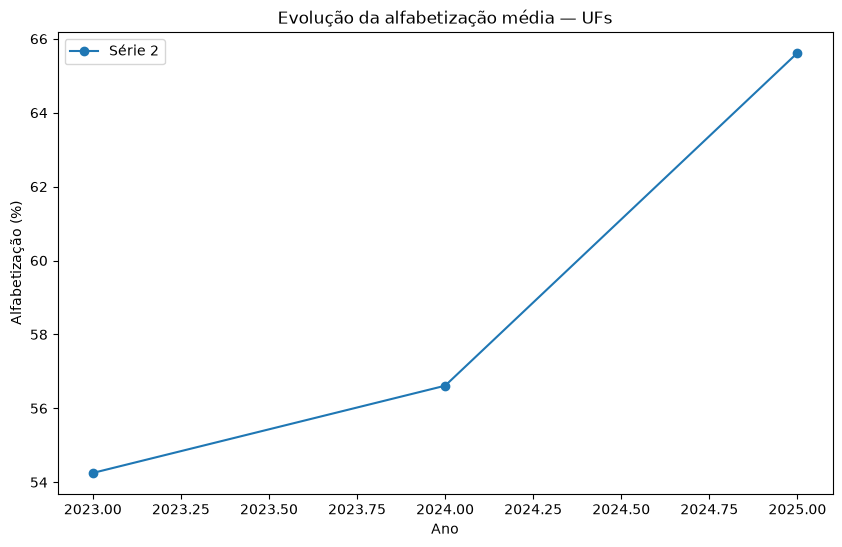

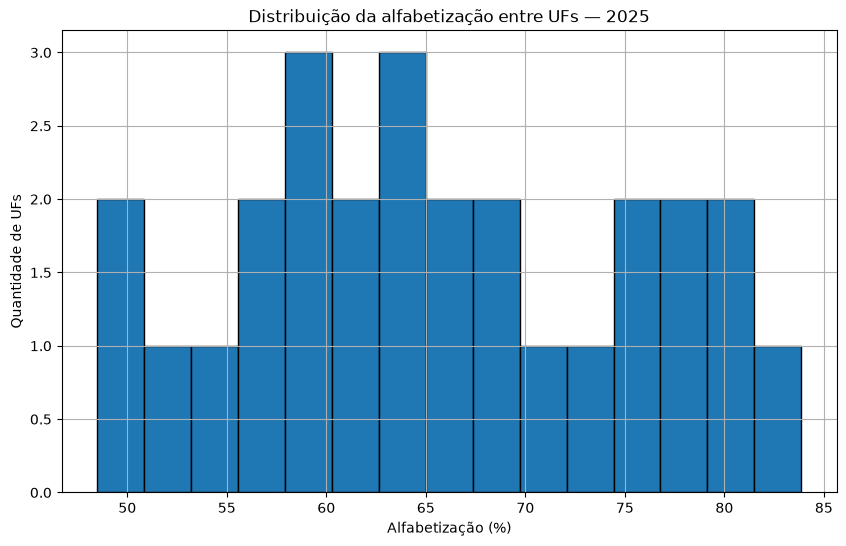

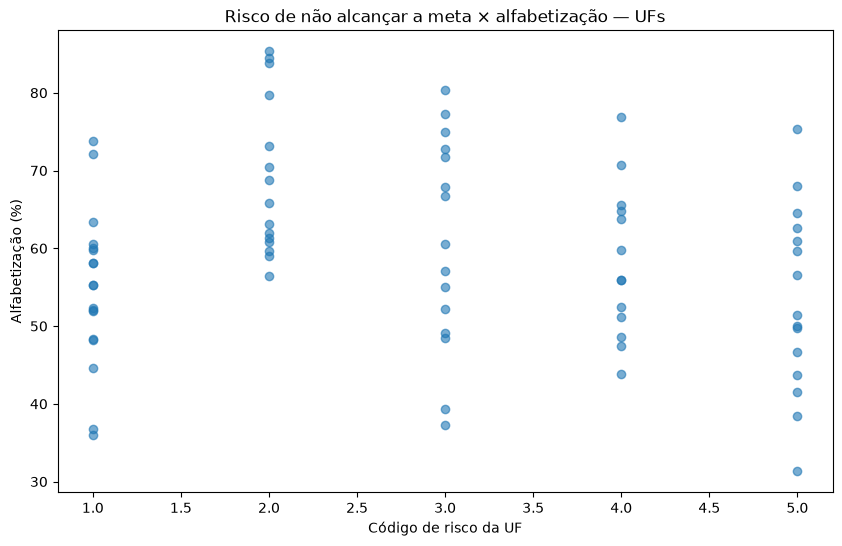

In [8]:
# Evolução da alfabetização média entre UFs
plt.figure(figsize=(10, 6))
for serie, grupo in analise_uf.groupby("TP_SERIE"):
    resumo = grupo.groupby("NU_ANO_AVALIACAO", as_index=False)["ALFABETIZACAO_UF"].mean()
    plt.plot(resumo["NU_ANO_AVALIACAO"], resumo["ALFABETIZACAO_UF"], marker="o", label=f"Série {serie}")
plt.title("Evolução da alfabetização média — UFs")
plt.xlabel("Ano")
plt.ylabel("Alfabetização (%)")
plt.legend()
plt.show()

# Distribuição do desempenho estadual no último ano
plt.figure(figsize=(10, 6))
ranking_uf["ALFABETIZACAO_UF"].dropna().hist(bins=15, edgecolor="black")
plt.title(f"Distribuição da alfabetização entre UFs — {ano_uf}")
plt.xlabel("Alfabetização (%)")
plt.ylabel("Quantidade de UFs")
plt.show()

# Relação entre risco UF e alfabetização
if {"COD_RISCO_UF", "ALFABETIZACAO_UF"}.issubset(analise_uf.columns):
    plot_uf = analise_uf[["COD_RISCO_UF", "ALFABETIZACAO_UF"]].dropna()
    if not plot_uf.empty:
        plt.figure(figsize=(10, 6))
        plt.scatter(plot_uf["COD_RISCO_UF"], plot_uf["ALFABETIZACAO_UF"], alpha=0.6)
        plt.xlabel("Código de risco da UF")
        plt.ylabel("Alfabetização (%)")
        plt.title("Risco de não alcançar a meta × alfabetização — UFs")
        plt.show()

# PARTE B — ANÁLISE POR MUNICÍPIO

**Grão analítico:** `CO_UF + CO_MUNICIPIO + Ano + Série`.

Nesta seção o município é a unidade de análise. Os indicadores estaduais serão usados somente como referência para comparação.

## 8. Preparação da base municipal

In [9]:
colunas_mun = [
    "NU_ANO_AVALIACAO", "CO_UF", "CO_MUNICIPIO", "TP_SERIE",
    "VL_MEDIA_LP", "PC_ALUNO_ALFABETIZADO"
]
faltantes = [c for c in colunas_mun if c not in df_municipios.columns]
if faltantes:
    raise KeyError(f"TS_MUNICIPIO sem colunas necessárias: {faltantes}")
if "ID_TIPO_REDE" not in df_municipios.columns:
    raise KeyError("TS_MUNICIPIO não possui ID_TIPO_REDE.")

df_mun = df_municipios.loc[
    df_municipios["ID_TIPO_REDE"].eq(5), colunas_mun
].copy()

df_mun = df_mun.rename(columns={
    "VL_MEDIA_LP": "MEDIA_LP_MUNICIPIO",
    "PC_ALUNO_ALFABETIZADO": "ALFABETIZACAO_MUNICIPIO"
})

chave_mun = ["NU_ANO_AVALIACAO", "CO_UF", "CO_MUNICIPIO", "TP_SERIE"]
validar_chave_unica(df_mun, chave_mun, "TS_MUNICIPIO — Total Geral")
print("Base Município:", df_mun.shape)
display(df_mun.head())

TS_MUNICIPIO — Total Geral: 16,019 registros | 0 duplicidades na chave
Base Município: (16019, 6)


,NU_ANO_AVALIACAO,CO_UF,CO_MUNICIPIO,TP_SERIE,MEDIA_LP_MUNICIPIO,ALFABETIZACAO_MUNICIPIO
0,2023,11,1100015,2,758.3304,64.55
3,2023,11,1100023,2,757.0999,62.30
4,2023,11,1100031,2,767.8763,69.10
6,2023,11,1100049,2,757.0954,63.37
10,2023,11,1100056,2,746.4629,58.53


## 9. Metas e dados externos por Município

In [10]:
df_metas_mun = preparar_metas(
    resultado_metas_muni,
    ["NU_ANO_AVALIACAO", "CO_UF", "CO_MUNICIPIO"],
    "MUNICIPIO"
)

analise_municipio = df_mun.merge(
    df_metas_mun,
    on=["NU_ANO_AVALIACAO", "CO_UF", "CO_MUNICIPIO"],
    how="left",
    validate="many_to_one"
)

if fact_municipio is not None:
    cols_ext = [
        "NU_ANO_AVALIACAO", "CO_UF", "CO_MUNICIPIO", "FUN_02_CAT_0",
        "COD_RISCO_UF", "CATEGORIA_RISCO_UF",
        "COD_RISCO_MUNICIPIO", "CATEGORIA_RISCO_MUNICIPIO",
        "NIVEL_RISCO_DESC_MUNICIPIO", "UF_POPULACAO_MIL",
        "UF_TAXA_ANALFABETISMO_PCT", "UF_RENDIMENTO_MEDIO_MENSAL_REAIS",
        "UF_RENDA_PERCAPITA_SBENEF_MEDIO", "UF_TAXA_FREQ_LIQUIDA_FUND_PCT",
        "UF_TIPO_DADO"
    ]
    cols_ext = [c for c in cols_ext if c in fact_municipio.columns]
    ext = fact_municipio[cols_ext].copy()
    chave_ext = ["NU_ANO_AVALIACAO", "CO_UF", "CO_MUNICIPIO"]
    ext = ext.sort_values(chave_ext).drop_duplicates(chave_ext, keep="first")

    analise_municipio = analise_municipio.merge(
        ext,
        on=chave_ext,
        how="left",
        validate="many_to_one"
    )

analise_municipio["META_MUNICIPIO_REFERENCIA"] = escolher_meta_ano(analise_municipio, "MUNICIPIO")
analise_municipio["DIF_META_MUNICIPIO"] = (
    analise_municipio["ALFABETIZACAO_MUNICIPIO"]
    - analise_municipio["META_MUNICIPIO_REFERENCIA"]
)
analise_municipio["ATINGIU_META_MUNICIPIO"] = analise_municipio["DIF_META_MUNICIPIO"].ge(0)

print("Base analítica Município:", analise_municipio.shape)
display(analise_municipio.head())

Metas MUNICIPIO: 16,286 registros | 0 duplicidades na chave
Base analítica Município: (16019, 27)


,NU_ANO_AVALIACAO,CO_UF,CO_MUNICIPIO,TP_SERIE,MEDIA_LP_MUNICIPIO,ALFABETIZACAO_MUNICIPIO,META_MUNICIPIO_FINAL_2024,META_MUNICIPIO_FINAL_2025,META_MUNICIPIO_FINAL_2026,META_MUNICIPIO_FINAL_2027,...,CATEGORIA_RISCO_MUNICIPIO,NIVEL_RISCO_DESC_MUNICIPIO,UF_POPULACAO_MIL,UF_TAXA_ANALFABETISMO_PCT,UF_RENDIMENTO_MEDIO_MENSAL_REAIS,UF_RENDA_PERCAPITA_SBENEF_MEDIO,UF_TAXA_FREQ_LIQUIDA_FUND_PCT,META_MUNICIPIO_REFERENCIA,DIF_META_MUNICIPIO,ATINGIU_META_MUNICIPIO
0,2023,11,1100015,2,758.3304,64.55,67.078601,69.512028,71.841093,74.058634,...,Baixo,2 – Risco moderado-baixo de não alcançar a meta,94,5.1,2916,1524.801152,89.593066,NaN,NaN,False
1,2023,11,1100023,2,757.0999,62.30,65.216878,68.023909,70.706161,73.251889,...,Muito baixo,1 – Baixo risco de não alcançar a meta,94,5.1,2916,1524.801152,89.593066,NaN,NaN,False
2,2023,11,1100031,2,767.8763,69.10,70.845029,72.530686,74.154438,75.714346,...,Muito alto,5 – Alto risco de não alcançar a meta,94,5.1,2916,1524.801152,89.593066,NaN,NaN,False
3,2023,11,1100049,2,757.0954,63.37,65.390716,68.162817,70.811990,73.326986,...,Muito baixo,1 – Baixo risco de não alcançar a meta,94,5.1,2916,1524.801152,89.593066,NaN,NaN,False
4,2023,11,1100056,2,746.4629,58.53,62.090401,65.525172,68.805091,71.906748,...,Baixo,2 – Risco moderado-baixo de não alcançar a meta,94,5.1,2916,1524.801152,89.593066,NaN,NaN,False


## 10. Indicadores e ranking por Município

In [11]:
print("=== RESUMO MUNICIPAL POR ANO ===")
resumo_mun_ano = (
    analise_municipio.groupby("NU_ANO_AVALIACAO", as_index=False)
    .agg(
        MEDIA_LP_MUNICIPIO=("MEDIA_LP_MUNICIPIO", "mean"),
        ALFABETIZACAO_MUNICIPIO=("ALFABETIZACAO_MUNICIPIO", "mean"),
        DIF_META_MUNICIPIO=("DIF_META_MUNICIPIO", "mean"),
        MUNICIPIOS=("CO_MUNICIPIO", "nunique")
    )
)
display(resumo_mun_ano.round(2))

ano_mun = int(analise_municipio["NU_ANO_AVALIACAO"].max())
ranking_municipios = (
    analise_municipio.loc[analise_municipio["NU_ANO_AVALIACAO"].eq(ano_mun)]
    .sort_values(["ALFABETIZACAO_MUNICIPIO", "MEDIA_LP_MUNICIPIO"], ascending=[True, True])
    .copy()
)

# Prioridade municipal: desempenho abaixo da meta + risco elevado.
def classificar_prioridade(row):
    risco = row.get("COD_RISCO_MUNICIPIO")
    dif = row.get("DIF_META_MUNICIPIO")
    if pd.notna(risco) and risco >= 4 and pd.notna(dif) and dif < 0:
        return "Prioridade máxima"
    if pd.notna(risco) and risco >= 4:
        return "Alta prioridade"
    if pd.notna(dif) and dif < 0:
        return "Atenção"
    return "Acompanhamento"

analise_municipio["PRIORIDADE"] = analise_municipio.apply(classificar_prioridade, axis=1)
ranking_municipios["PRIORIDADE"] = ranking_municipios.apply(classificar_prioridade, axis=1)

cols_rank_mun = [c for c in [
    "NU_ANO_AVALIACAO", "CO_UF", "CO_MUNICIPIO", "TP_SERIE",
    "MEDIA_LP_MUNICIPIO", "ALFABETIZACAO_MUNICIPIO",
    "META_MUNICIPIO_REFERENCIA", "GAP_META_MUNICIPIO",
    "ATINGIU_META_MUNICIPIO", "COD_RISCO_MUNICIPIO",
    "CATEGORIA_RISCO_MUNICIPIO", "FUN_02_CAT_0", "PRIORIDADE"
] if c in ranking_municipios.columns]

display(ranking_municipios[cols_rank_mun].head(20).round(2))

print("=== DISTRIBUIÇÃO DE PRIORIDADE ===")
display(
    analise_municipio["PRIORIDADE"]
    .value_counts(dropna=False)
    .rename_axis("PRIORIDADE")
    .reset_index(name="REGISTROS")
)

=== RESUMO MUNICIPAL POR ANO ===


,NU_ANO_AVALIACAO,MEDIA_LP_MUNICIPIO,ALFABETIZACAO_MUNICIPIO,DIF_META_MUNICIPIO,MUNICIPIOS
0,2023,750.34,60.47,NaN,4950
1,2024,753.23,63.17,1.37,5516
2,2025,760.57,72.08,7.01,5553


,NU_ANO_AVALIACAO,CO_UF,CO_MUNICIPIO,TP_SERIE,MEDIA_LP_MUNICIPIO,ALFABETIZACAO_MUNICIPIO,META_MUNICIPIO_REFERENCIA,ATINGIU_META_MUNICIPIO,COD_RISCO_MUNICIPIO,CATEGORIA_RISCO_MUNICIPIO,FUN_02_CAT_0,PRIORIDADE
15279,2025,43,4310876,2,724.20,11.11,61.0,False,2.0,Baixo,4.0,Atenção
15166,2025,43,4305371,2,724.68,11.76,64.0,False,2.0,Baixo,4.3,Atenção
10828,2025,17,1707702,2,691.49,12.84,26.0,False,1.0,Muito baixo,7.0,Atenção
12283,2025,28,2807006,2,693.35,15.74,52.0,False,4.0,Alto,6.7,Prioridade máxima
13034,2025,31,3129103,2,726.16,19.05,78.0,False,2.0,Baixo,4.4,Atenção
15271,2025,43,4310553,2,686.19,20.59,80.0,False,2.0,Baixo,5.3,Atenção
11642,2025,24,2409332,2,685.89,20.91,58.0,False,2.0,Baixo,4.0,Atenção
12586,2025,29,2924207,2,698.94,21.39,44.0,False,1.0,Muito baixo,4.3,Atenção
11811,2025,25,2508406,2,715.34,22.20,36.0,False,3.0,Moderado,7.6,Atenção
11571,2025,24,2402808,2,713.84,22.84,53.0,False,2.0,Baixo,4.5,Atenção


=== DISTRIBUIÇÃO DE PRIORIDADE ===


,PRIORIDADE,REGISTROS
0,Acompanhamento,7044
1,Alta prioridade,5050
2,Atenção,2707
3,Prioridade máxima,1218


## 11. Visualizações — análise por Município

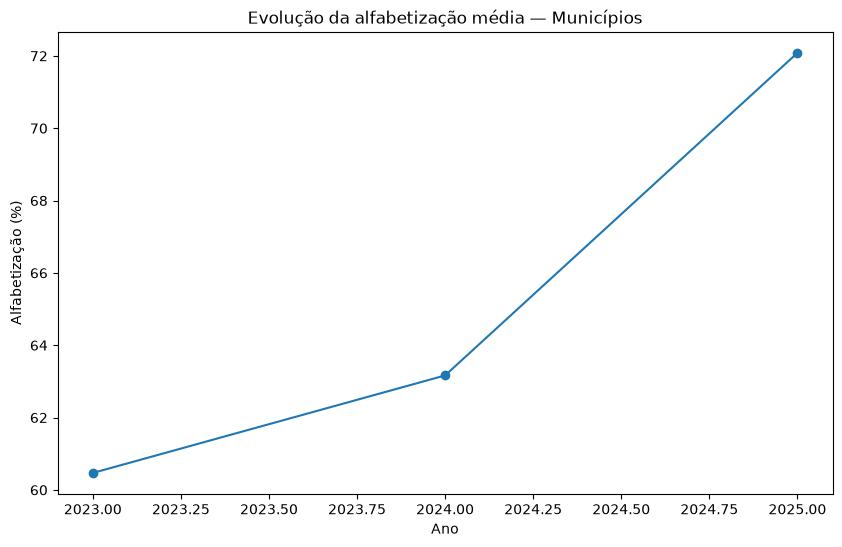

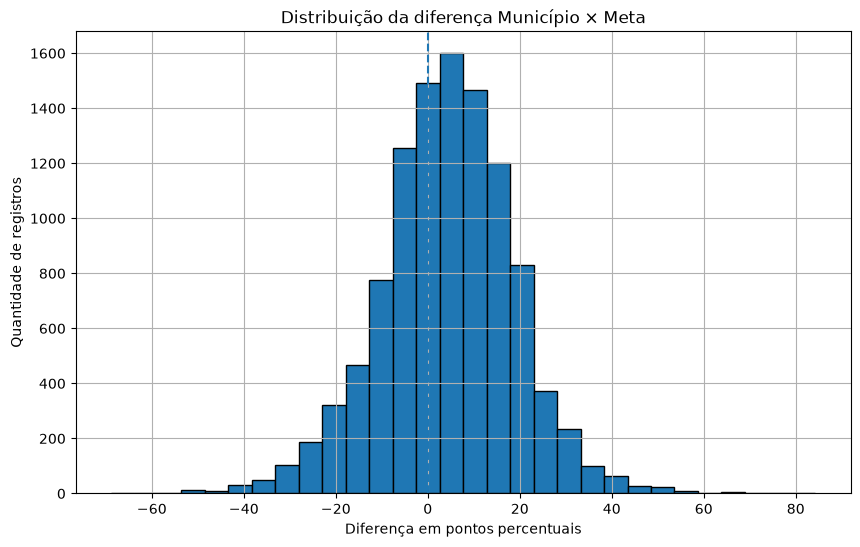

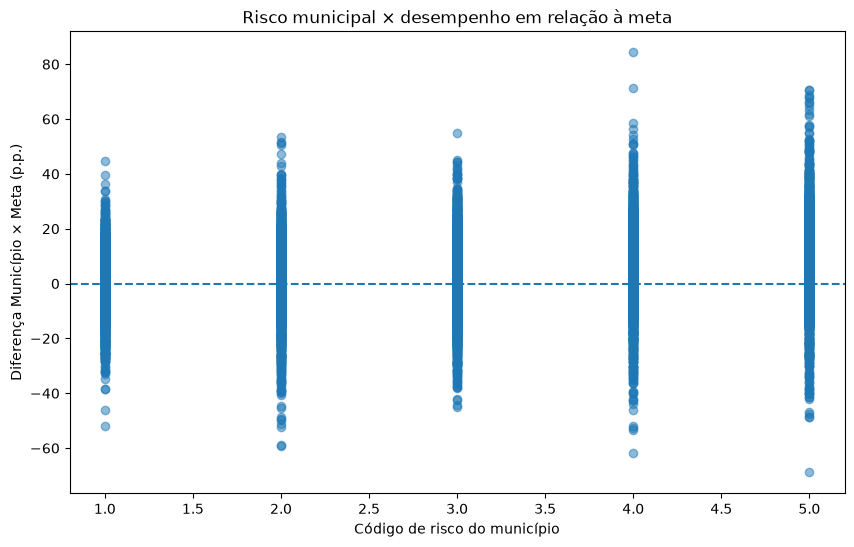

In [12]:
# Evolução média municipal
plt.figure(figsize=(10, 6))
resumo = analise_municipio.groupby("NU_ANO_AVALIACAO", as_index=False)["ALFABETIZACAO_MUNICIPIO"].mean()
plt.plot(resumo["NU_ANO_AVALIACAO"], resumo["ALFABETIZACAO_MUNICIPIO"], marker="o")
plt.title("Evolução da alfabetização média — Municípios")
plt.xlabel("Ano")
plt.ylabel("Alfabetização (%)")
plt.show()

# Distribuição do gap em relação à meta
plt.figure(figsize=(10, 6))
analise_municipio["DIF_META_MUNICIPIO"].dropna().hist(bins=30, edgecolor="black")
plt.axvline(0, linestyle="--")
plt.title("Distribuição da diferença Município × Meta")
plt.xlabel("Diferença em pontos percentuais")
plt.ylabel("Quantidade de registros")
plt.show()

# Risco municipal × gap da meta
if {"COD_RISCO_MUNICIPIO", "DIF_META_MUNICIPIO"}.issubset(analise_municipio.columns):
    plot_mun = analise_municipio[["COD_RISCO_MUNICIPIO", "DIF_META_MUNICIPIO"]].dropna()
    if not plot_mun.empty:
        plt.figure(figsize=(10, 6))
        plt.scatter(plot_mun["COD_RISCO_MUNICIPIO"], plot_mun["DIF_META_MUNICIPIO"], alpha=0.5)
        plt.axhline(0, linestyle="--")
        plt.xlabel("Código de risco do município")
        plt.ylabel("Diferença Município × Meta (p.p.)")
        plt.title("Risco municipal × desempenho em relação à meta")
        plt.show()

# PARTE C — ANÁLISE CRUZADA MUNICÍPIO × UF

Agora comparamos diretamente cada município com a **referência estadual correspondente**, preservando o grão municipal.

## 12. Cruzamento Município × UF

In [13]:
comparativo_mun_uf = analise_municipio.merge(
    df_uf,
    on=["NU_ANO_AVALIACAO", "CO_UF", "TP_SERIE"],
    how="left",
    validate="many_to_one",
    suffixes=("", "_REF")
)

comparativo_mun_uf["DIF_MEDIA_LP_MUN_UF"] = (
    comparativo_mun_uf["MEDIA_LP_MUNICIPIO"]
    - comparativo_mun_uf["MEDIA_LP_UF"]
)
comparativo_mun_uf["DIF_ALFABETIZACAO_MUN_UF"] = (
    comparativo_mun_uf["ALFABETIZACAO_MUNICIPIO"]
    - comparativo_mun_uf["ALFABETIZACAO_UF"]
)
comparativo_mun_uf["POSICAO_VS_UF"] = pd.cut(
    comparativo_mun_uf["DIF_ALFABETIZACAO_MUN_UF"],
    bins=[-np.inf, -5, 5, np.inf],
    labels=["Abaixo da UF", "Próximo da UF", "Acima da UF"]
)

# Prioridade final incorpora a comparação com a UF.
def prioridade_final(row):
    risco = row.get("COD_RISCO_MUNICIPIO")
    gap_uf = row.get("DIF_ALFABETIZACAO_MUN_UF")
    gap_meta = row.get("DIF_META_MUNICIPIO")
    if pd.notna(risco) and risco >= 4 and (
        (pd.notna(gap_meta) and gap_meta < 0) or
        (pd.notna(gap_uf) and gap_uf < -5)
    ):
        return "Prioridade máxima"
    if pd.notna(risco) and risco >= 4:
        return "Alta prioridade"
    if pd.notna(gap_meta) and gap_meta < 0:
        return "Atenção"
    if pd.notna(gap_uf) and gap_uf < -5:
        return "Atenção"
    return "Acompanhamento"

comparativo_mun_uf["PRIORIDADE"] = comparativo_mun_uf.apply(prioridade_final, axis=1)

chave_final = ["NU_ANO_AVALIACAO", "CO_UF", "CO_MUNICIPIO", "TP_SERIE"]
validar_chave_unica(comparativo_mun_uf, chave_final, "Base final Município × UF")

print("Base final Município × UF:", comparativo_mun_uf.shape)
display(comparativo_mun_uf.head())

Base final Município × UF: 16,019 registros | 0 duplicidades na chave
Base final Município × UF: (16019, 33)


,NU_ANO_AVALIACAO,CO_UF,CO_MUNICIPIO,TP_SERIE,MEDIA_LP_MUNICIPIO,ALFABETIZACAO_MUNICIPIO,META_MUNICIPIO_FINAL_2024,META_MUNICIPIO_FINAL_2025,META_MUNICIPIO_FINAL_2026,META_MUNICIPIO_FINAL_2027,...,UF_TAXA_FREQ_LIQUIDA_FUND_PCT,META_MUNICIPIO_REFERENCIA,DIF_META_MUNICIPIO,ATINGIU_META_MUNICIPIO,PRIORIDADE,MEDIA_LP_UF,ALFABETIZACAO_UF,DIF_MEDIA_LP_MUN_UF,DIF_ALFABETIZACAO_MUN_UF,POSICAO_VS_UF
0,2023,11,1100015,2,758.3304,64.55,67.078601,69.512028,71.841093,74.058634,...,89.593066,NaN,NaN,False,Acompanhamento,759.4357,64.6,-1.1053,-0.05,Próximo da UF
1,2023,11,1100023,2,757.0999,62.30,65.216878,68.023909,70.706161,73.251889,...,89.593066,NaN,NaN,False,Acompanhamento,759.4357,64.6,-2.3358,-2.30,Próximo da UF
2,2023,11,1100031,2,767.8763,69.10,70.845029,72.530686,74.154438,75.714346,...,89.593066,NaN,NaN,False,Alta prioridade,759.4357,64.6,8.4406,4.50,Próximo da UF
3,2023,11,1100049,2,757.0954,63.37,65.390716,68.162817,70.811990,73.326986,...,89.593066,NaN,NaN,False,Acompanhamento,759.4357,64.6,-2.3403,-1.23,Próximo da UF
4,2023,11,1100056,2,746.4629,58.53,62.090401,65.525172,68.805091,71.906748,...,89.593066,NaN,NaN,False,Atenção,759.4357,64.6,-12.9728,-6.07,Abaixo da UF


## 13. Resumo executivo e municípios prioritários

In [14]:
print("=== RESUMO DO CRUZAMENTO ===")
resumo_cruzado = (
    comparativo_mun_uf.groupby("NU_ANO_AVALIACAO", as_index=False)
    .agg(
        MEDIA_LP_MUNICIPIO=("MEDIA_LP_MUNICIPIO", "mean"),
        MEDIA_LP_UF=("MEDIA_LP_UF", "mean"),
        DIF_MEDIA_LP_MUN_UF=("DIF_MEDIA_LP_MUN_UF", "mean"),
        ALFABETIZACAO_MUNICIPIO=("ALFABETIZACAO_MUNICIPIO", "mean"),
        ALFABETIZACAO_UF=("ALFABETIZACAO_UF", "mean"),
        DIF_ALFABETIZACAO_MUN_UF=("DIF_ALFABETIZACAO_MUN_UF", "mean")
    )
)
display(resumo_cruzado.round(2))

print("=== POSIÇÃO DO MUNICÍPIO EM RELAÇÃO À UF ===")
display(
    comparativo_mun_uf["POSICAO_VS_UF"]
    .value_counts(dropna=False)
    .rename_axis("POSICAO")
    .reset_index(name="REGISTROS")
)

print("=== MUNICÍPIOS PRIORITÁRIOS ===")
ranking_prioridade = (
    comparativo_mun_uf
    .sort_values(
        ["NU_ANO_AVALIACAO", "PRIORIDADE", "DIF_ALFABETIZACAO_MUN_UF", "DIF_META_MUNICIPIO"],
        ascending=[False, True, True, True]
    )
    .copy()
)

cols_prioridade = [c for c in [
    "NU_ANO_AVALIACAO", "CO_UF", "CO_MUNICIPIO", "TP_SERIE",
    "MEDIA_LP_MUNICIPIO", "MEDIA_LP_UF", "DIF_MEDIA_LP_MUN_UF",
    "ALFABETIZACAO_MUNICIPIO", "ALFABETIZACAO_UF",
    "DIF_ALFABETIZACAO_MUN_UF", "META_MUNICIPIO_REFERENCIA",
    "DIF_META_MUNICIPIO", "COD_RISCO_MUNICIPIO",
    "CATEGORIA_RISCO_MUNICIPIO", "PRIORIDADE"
] if c in ranking_prioridade.columns]

display(ranking_prioridade[cols_prioridade].head(30).round(2))

=== RESUMO DO CRUZAMENTO ===


,NU_ANO_AVALIACAO,MEDIA_LP_MUNICIPIO,MEDIA_LP_UF,DIF_MEDIA_LP_MUN_UF,ALFABETIZACAO_MUNICIPIO,ALFABETIZACAO_UF,DIF_ALFABETIZACAO_MUN_UF
0,2023,750.34,745.89,4.45,60.47,56.86,3.61
1,2024,753.23,748.13,5.10,63.17,58.84,4.33
2,2025,760.57,753.79,6.78,72.08,66.47,5.61


=== POSIÇÃO DO MUNICÍPIO EM RELAÇÃO À UF ===


,POSICAO,REGISTROS
0,Acima da UF,7766
1,Próximo da UF,4385
2,Abaixo da UF,3867
3,NaN,1


=== MUNICÍPIOS PRIORITÁRIOS ===


,NU_ANO_AVALIACAO,CO_UF,CO_MUNICIPIO,TP_SERIE,MEDIA_LP_MUNICIPIO,MEDIA_LP_UF,DIF_MEDIA_LP_MUN_UF,ALFABETIZACAO_MUNICIPIO,ALFABETIZACAO_UF,DIF_ALFABETIZACAO_MUN_UF,META_MUNICIPIO_REFERENCIA,DIF_META_MUNICIPIO,COD_RISCO_MUNICIPIO,CATEGORIA_RISCO_MUNICIPIO,PRIORIDADE
12654,2025,29,2929701,2,732.91,737.32,-4.40,50.32,55.32,-5.00,31.0,19.32,3.0,Moderado,Acompanhamento
12158,2025,27,2704203,2,745.35,750.94,-5.60,58.78,63.77,-4.99,55.0,3.78,1.0,Muito baixo,Acompanhamento
15765,2025,51,5108402,2,759.22,764.26,-5.04,69.97,74.92,-4.95,58.0,11.97,1.0,Muito baixo,Acompanhamento
11820,2025,25,2509107,2,747.93,760.60,-12.67,65.73,70.68,-4.95,51.0,14.73,2.0,Baixo,Acompanhamento
12990,2025,31,3125606,2,760.07,760.76,-0.69,68.90,73.83,-4.93,61.0,7.90,3.0,Moderado,Acompanhamento
10661,2025,15,1502905,2,737.55,742.47,-4.92,53.15,58.05,-4.90,NaN,NaN,NaN,NaN,Acompanhamento
15816,2025,52,5204250,2,758.33,770.45,-12.12,75.46,80.33,-4.87,75.0,0.46,3.0,Moderado,Acompanhamento
15617,2025,50,5007406,2,742.07,751.71,-9.64,60.78,65.62,-4.84,58.0,2.78,2.0,Baixo,Acompanhamento
14679,2025,41,4122206,2,760.86,767.81,-6.95,74.87,79.69,-4.82,68.0,6.87,1.0,Muito baixo,Acompanhamento
14670,2025,41,4121604,2,762.19,767.81,-5.62,74.89,79.69,-4.80,74.0,0.89,3.0,Moderado,Acompanhamento


## 14. Visualizações — Município × UF

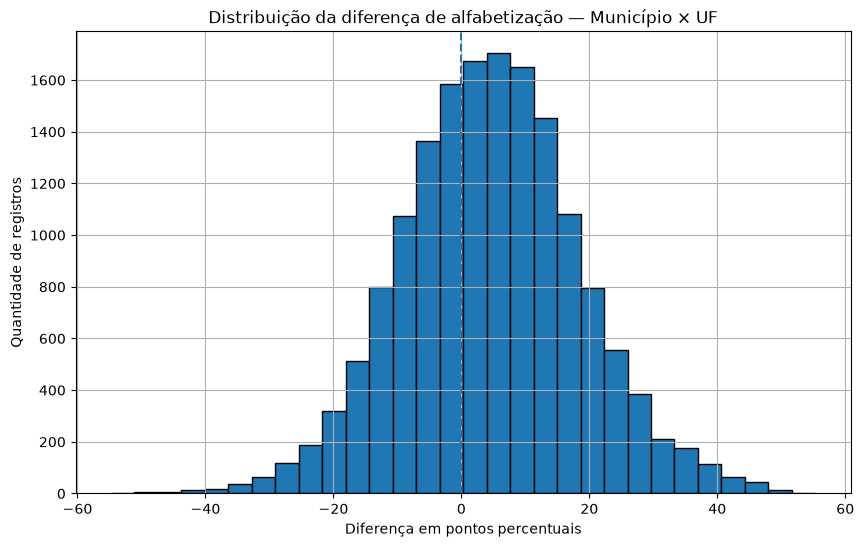

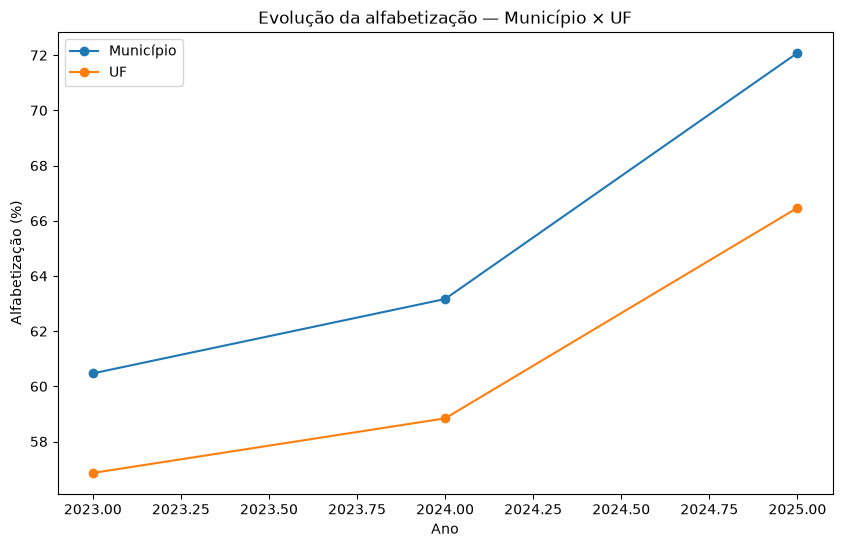

In [15]:
# Distribuição da diferença de alfabetização Município × UF
plt.figure(figsize=(10, 6))
comparativo_mun_uf["DIF_ALFABETIZACAO_MUN_UF"].dropna().hist(bins=30, edgecolor="black")
plt.axvline(0, linestyle="--")
plt.title("Distribuição da diferença de alfabetização — Município × UF")
plt.xlabel("Diferença em pontos percentuais")
plt.ylabel("Quantidade de registros")
plt.show()

# Evolução agregada: Município versus UF
plt.figure(figsize=(10, 6))
plt.plot(resumo_cruzado["NU_ANO_AVALIACAO"], resumo_cruzado["ALFABETIZACAO_MUNICIPIO"], marker="o", label="Município")
plt.plot(resumo_cruzado["NU_ANO_AVALIACAO"], resumo_cruzado["ALFABETIZACAO_UF"], marker="o", label="UF")
plt.title("Evolução da alfabetização — Município × UF")
plt.xlabel("Ano")
plt.ylabel("Alfabetização (%)")
plt.legend()
plt.show()

## 15. Validação final e exportação dos produtos analíticos

São gerados três produtos:

- `analise_uf`: análise no grão UF × Ano × Série.
- `analise_municipio`: análise no grão Município × UF × Ano × Série.
- `ranking_prioridade`: ranking municipal para apoio à decisão.

Os arquivos Excel são salvos no diretório atual do notebook.

In [22]:
print("=== VALIDAÇÕES FINAIS ===")
validar_chave_unica(analise_uf, ["NU_ANO_AVALIACAO", "CO_UF", "TP_SERIE"], "analise_uf")
validar_chave_unica(analise_municipio, chave_mun, "analise_municipio")
validar_chave_unica(comparativo_mun_uf, chave_final, "comparativo_mun_uf")

print("Cobertura da análise UF:")
for c, n in [("META_UF_REFERENCIA", "Meta UF"), ("COD_RISCO_UF", "Risco UF")]:
    cobertura(analise_uf, c, n)

print("Cobertura da análise Município:")
for c, n in [("META_MUNICIPIO_REFERENCIA", "Meta Município"), ("COD_RISCO_MUNICIPIO", "Risco Município")]:
    cobertura(analise_municipio, c, n)

# Exportação
#analise_uf.to_excel("analise_uf.xlsx", index=False)
#analise_municipio.to_excel("analise_municipio.xlsx", index=False)
#ranking_prioridade[cols_prioridade].to_excel("ranking_prioridade.xlsx", index=False)

salvar_parquet(analise_uf, os.path.join(GOLD_DIR, "analise_uf.parquet"))
salvar_parquet(analise_municipio, os.path.join(GOLD_DIR, "analise_municipio.parquet"))
salvar_parquet(ranking_prioridade, os.path.join(GOLD_DIR, "ranking_prioridade.parquet"))

print("Arquivos gerados:")
print(os.path.abspath("analise_uf.parquet"))
print(os.path.abspath("analise_municipio.parquet"))
print(os.path.abspath("ranking_prioridade.parquet"))

=== VALIDAÇÕES FINAIS ===
analise_uf: 76 registros | 0 duplicidades na chave
analise_municipio: 16,019 registros | 0 duplicidades na chave
comparativo_mun_uf: 16,019 registros | 0 duplicidades na chave
Cobertura da análise UF:
Meta UF: 64.47% preenchido
Risco UF: 100.00% preenchido
Cobertura da análise Município:
Meta Município: 66.48% preenchido
Risco Município: 98.36% preenchido
Arquivos gerados:
c:\Users\jack_\OneDrive\Área de Trabalho\TECH CHALLENGE 3\fiap_tech_challenge_03\notebooks\analise_uf.parquet
c:\Users\jack_\OneDrive\Área de Trabalho\TECH CHALLENGE 3\fiap_tech_challenge_03\notebooks\analise_municipio.parquet
c:\Users\jack_\OneDrive\Área de Trabalho\TECH CHALLENGE 3\fiap_tech_challenge_03\notebooks\ranking_prioridade.parquet


### Subir para o S3

In [23]:
from src.data.utils import *
import boto3

session = iniciar_cessao_aws()
s3 = session.client("s3")

BUCKET = os.getenv("BUCKET_NAME")

pasta_atual = Path().resolve()
caminho_env = pasta_atual.parent / '.env'

dotenv.load_dotenv(caminho_env)


True

In [24]:
from pathlib import Path

# Aponta diretamente para a sua pasta src/data/gold
PASTA_GOLD = Path.cwd().parent / "src" / "data" / "gold"


for arquivo in PASTA_GOLD.glob("*.parquet"):
    chave_s3 = f"gold/dados_externos/{arquivo.name}"
    
    print(f"Enviando {arquivo.name} para s3://{BUCKET}/{chave_s3}...")
    
    s3.upload_file(
        Filename=str(arquivo),
        Bucket=BUCKET,
        Key=chave_s3
    )

print("\n✅ Todos os arquivos Gold foram enviados com sucesso!")


Enviando analise_municipio.parquet para s3://postech-challenge-datascience-003/gold/dados_externos/analise_municipio.parquet...
Enviando analise_uf.parquet para s3://postech-challenge-datascience-003/gold/dados_externos/analise_uf.parquet...
Enviando dim_contexto_socioeconomico_uf.parquet para s3://postech-challenge-datascience-003/gold/dados_externos/dim_contexto_socioeconomico_uf.parquet...
Enviando fact_escola.parquet para s3://postech-challenge-datascience-003/gold/dados_externos/fact_escola.parquet...
Enviando fact_municipio.parquet para s3://postech-challenge-datascience-003/gold/dados_externos/fact_municipio.parquet...
Enviando ranking_prioridade.parquet para s3://postech-challenge-datascience-003/gold/dados_externos/ranking_prioridade.parquet...

✅ Todos os arquivos Gold foram enviados com sucesso!
